# Phase 4 Comic Generation Validation

This notebook now focuses on the latest Google image models as of April 13, 2026.

If you click `Run All`, it will:

- call the comic metadata endpoint once
- test the latest fast Google image model: `gemini-3.1-flash-image-preview` (`Nano Banana 2 Preview`)
- test the latest standard/pro Google image model: `gemini-3-pro-image-preview` (`Nano Banana Pro Preview`)
- save both generated images under `artifacts/comic_generation_notebook/`
- display each generated image inline
- print per-model runtime and estimated billing

Before running it, start the 3.0 server from the repo root:

```powershell
npm.cmd run dev:server
```

This notebook automatically removes the built-in SVG placeholder reference images for real Gemini image calls, because the Gemini image API rejects `image/svg+xml` inline reference inputs. Character continuity is still reinforced through the generated page prompt text.


In [1]:
from __future__ import annotations

import base64
import json
import mimetypes
import os
import re
from base64 import b64decode
from datetime import datetime
from pathlib import Path
from time import perf_counter

import requests
from IPython.display import Image as IPyImage, SVG, display

repo_root = Path("f:/Documents/GitHub/AI_TRPG_616/version 3.0")
api_base_url = os.getenv("TRPG_COMIC_NOTEBOOK_API_BASE_URL", "http://127.0.0.1:4316")
output_dir = repo_root / "artifacts" / "comic_generation_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

print("Repo root:", repo_root)
print("API base URL:", api_base_url)
print("Output dir:", output_dir)


Repo root: f:\Documents\GitHub\AI_TRPG_616\version 3.0
API base URL: http://127.0.0.1:4318
Output dir: f:\Documents\GitHub\AI_TRPG_616\version 3.0\artifacts\comic_generation_notebook


In [2]:
def make_mock_reference_data_url(name: str, subtitle: str, fill: str) -> str:
    safe_name = name.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    safe_subtitle = subtitle.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="768" height="1024" viewBox="0 0 768 1024">
  <rect width="768" height="1024" fill="{fill}" />
  <circle cx="384" cy="300" r="160" fill="#f6eadf" fill-opacity="0.95" />
  <rect x="184" y="470" width="400" height="340" rx="48" fill="#111827" fill-opacity="0.22" />
  <text x="60" y="120" fill="#ffffff" font-family="Georgia, serif" font-size="54">Character Ref</text>
  <text x="60" y="188" fill="#ffffff" font-family="Georgia, serif" font-size="40">{safe_name}</text>
  <text x="60" y="240" fill="#ffffff" font-family="Georgia, serif" font-size="24">{safe_subtitle}</text>
</svg>'''
    encoded = base64.b64encode(svg.encode("utf-8")).decode("ascii")
    return f"data:image/svg+xml;base64,{encoded}"


def file_to_data_url(path: str | Path) -> str:
    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f"Image file not found: {file_path}")

    mime_type = mimetypes.guess_type(file_path.name)[0] or "application/octet-stream"
    raw = file_path.read_bytes()
    return f"data:{mime_type};base64,{base64.b64encode(raw).decode('ascii')}"


def ensure_server_available() -> None:
    try:
        response = requests.get(f"{api_base_url}/api/health", timeout=10)
        response.raise_for_status()
    except Exception as exc:
        raise RuntimeError(
            f"AI TRPG 3.0 server is not reachable at {api_base_url}. "
            "Start it in a separate terminal with: cd 'f:/Documents/GitHub/AI_TRPG_616/version 3.0' ; npm.cmd run dev:server"
        ) from exc


def post_json(path: str, payload: dict) -> dict:
    response = requests.post(f"{api_base_url}{path}", json=payload, timeout=300)
    if not response.ok:
        raise RuntimeError(f"{response.status_code} {response.text}")
    return response.json()


def get_json(path: str) -> dict:
    response = requests.get(f"{api_base_url}{path}", timeout=60)
    if not response.ok:
        raise RuntimeError(f"{response.status_code} {response.text}")
    return response.json()


def decode_image_payload(image_url: str) -> tuple[bytes, str]:
    if image_url.startswith("data:"):
        header, encoded = image_url.split(",", 1)
        mime_type = header.split(";", 1)[0].replace("data:", "", 1)
        return b64decode(encoded), mime_type

    response = requests.get(image_url, timeout=300)
    response.raise_for_status()
    mime_type = response.headers.get("content-type", "image/png").split(";", 1)[0]
    return response.content, mime_type


def save_generated_image(image_url: str, output_stem: str) -> Path:
    payload, mime_type = decode_image_payload(image_url)
    extension = mimetypes.guess_extension(mime_type) or ".png"
    if mime_type == "image/svg+xml":
        extension = ".svg"
    if mime_type == "image/jpeg":
        extension = ".jpg"

    target_path = output_dir / f"{output_stem}{extension}"
    target_path.write_bytes(payload)
    return target_path


def display_generated_image(path: Path) -> None:
    if path.suffix.lower() == ".svg":
        display(SVG(filename=str(path)))
    else:
        display(IPyImage(filename=str(path)))


def normalize_previous_pages(previous_pages: list[dict]) -> list[dict]:
    normalized = []
    for page in previous_pages:
        item = {
            "pageNumber": int(page["pageNumber"]),
            "prompt": str(page["prompt"]),
        }
        if page.get("summary"):
            item["summary"] = str(page["summary"])
        image_path = page.get("image_path")
        image_url = page.get("imageUrl")
        if image_path:
            item["imageUrl"] = file_to_data_url(image_path)
        elif image_url:
            item["imageUrl"] = str(image_url)
        normalized.append(item)
    return normalized


def normalize_reference_images(reference_images: list[dict]) -> list[dict]:
    normalized = []
    for item in reference_images:
        image_path = item.get("image_path")
        image_url = item.get("imageUrl")
        normalized_item = {
            "role": item.get("role", "character")
        }
        if item.get("name"):
            normalized_item["name"] = str(item["name"])
        if item.get("appearance"):
            normalized_item["appearance"] = str(item["appearance"])
        if image_path:
            normalized_item["imageUrl"] = file_to_data_url(image_path)
        elif image_url:
            normalized_item["imageUrl"] = str(image_url)
        else:
            raise ValueError(f"Missing image_path/imageUrl in reference image item: {item}")
        normalized.append(normalized_item)
    return normalized


def extract_estimated_cost(payload: dict | None) -> tuple[float | None, str | None]:
    if not payload:
        return None, None
    meta = payload.get("meta") if isinstance(payload, dict) else None
    estimated_cost = meta.get("estimatedCost") if isinstance(meta, dict) else None
    if not isinstance(estimated_cost, dict):
        return None, None
    amount = estimated_cost.get("amount")
    currency = estimated_cost.get("currency")
    if isinstance(amount, (int, float)) and isinstance(currency, str):
        return float(amount), currency
    return None, None


def format_cost(amount: float | None, currency: str | None) -> str:
    if amount is None or currency is None:
        return "unknown"
    return f"{amount:.4f} {currency}"


def is_svg_data_url(image_url: str) -> bool:
    return image_url.startswith("data:image/svg+xml")


def build_effective_reference_images(
    reference_images: list[dict],
    image_profile_id: str,
    keep_svg_placeholders_for_real_models: bool,
) -> list[dict]:
    normalized = normalize_reference_images(reference_images)
    if image_profile_id != "gemini-image" or keep_svg_placeholders_for_real_models:
        return normalized

    filtered = [item for item in normalized if not is_svg_data_url(item["imageUrl"])]
    if len(filtered) != len(normalized):
        print(
            "Removed SVG placeholder reference images for this real Gemini run because the Gemini image API rejects image/svg+xml inline references."
        )
    return filtered


GOOGLE_IMAGE_PRICE_TABLE = {
    "gemini-3.1-flash-image-preview": {
        "1K": 0.067,
        "2K": 0.101,
        "4K": 0.151,
    },
    "gemini-3-pro-image-preview": {
        "1K": 0.134,
        "2K": 0.134,
        "4K": 0.240,
    },
    "gemini-2.5-flash-image": {
        "1K": 0.039,
    },
}


def estimate_google_image_cost(model: str, image_size: str | None) -> tuple[float | None, str | None]:
    size = image_size or "1K"
    table = GOOGLE_IMAGE_PRICE_TABLE.get(model)
    if not table:
        return None, None
    if size in table:
        return table[size], "USD"
    if "1K" in table:
        return table["1K"], "USD"
    return None, "USD"


def make_output_stem(run_name: str) -> str:
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    safe_run_name = re.sub(r"[^a-zA-Z0-9_-]+", "-", run_name).strip("-").lower()
    return f"comic-page-{safe_run_name}-{timestamp}"


In [3]:
# Run All now exercises the latest documented Google image models as of 2026-04-13.

IMAGE_PROFILE_ID = "gemini-image"
STYLE_ID = "manga"
ALLOW_FALLBACK = False
KEEP_SVG_PLACEHOLDER_REFERENCES_FOR_REAL_MODELS = False
NEGATIVE_PROMPT = "blurry unreadable text duplicated faces broken anatomy watermark bad hands extra fingers"

# Keep metadata on mock so image billing is isolated and easier to read.
TEXT_MODEL_ACCESS_MODE = "mock"
TEXT_MODEL_PROFILE_ID = "chatgpt"
RUNTIME_TEXT_MODEL_CONFIG = {}
BASE_RUNTIME_IMAGE_MODEL_CONFIG = {
    "aspectRatio": "3:4",
    "imageSize": "1K",
}

LATEST_GOOGLE_IMAGE_RUNS = [
    {
        "runName": "google-fast-latest",
        "label": "Latest fast image model",
        "marketingName": "Nano Banana 2 Preview",
        "model": "gemini-3.1-flash-image-preview",
        "imageSize": "1K",
        "aspectRatio": "3:4",
        "docsUrl": "https://ai.google.dev/gemini-api/docs/image-generation",
        "pricingUrl": "https://ai.google.dev/gemini-api/docs/pricing",
    },
    {
        "runName": "google-pro-latest",
        "label": "Latest standard/pro image model",
        "marketingName": "Nano Banana Pro Preview",
        "model": "gemini-3-pro-image-preview",
        "imageSize": "1K",
        "aspectRatio": "3:4",
        "docsUrl": "https://ai.google.dev/gemini-api/docs/image-generation",
        "pricingUrl": "https://ai.google.dev/gemini-api/docs/pricing",
    },
]

STORY_PROMPT = '''Continue the story as page 2 of a supernatural subway mystery. Lin Yue, a rookie exorcist with a yellow raincoat over her school uniform, steps onto the flooded platform while Mori Akira, a tired rail engineer in a dark navy coat and white gloves, shines a maintenance lantern toward a ghost train arriving out of black water. Across five panels, show the train doors opening, rows of pale passengers turning to stare at them in unison, Lin gripping her prayer beads, Akira realizing the train number matches the line that vanished ten years ago, and the final panel ending on a close-up of one passenger holding Lin's childhood umbrella.''' 

REFERENCE_IMAGES = [
    {
        "role": "character",
        "name": "Lin Yue",
        "appearance": "young East Asian woman, short black bob haircut, amber raincoat over a school uniform, anxious but determined expression, prayer beads wrapped around one hand",
        "imageUrl": make_mock_reference_data_url("Lin Yue", "rookie exorcist", "#b45309"),
    },
    {
        "role": "character",
        "name": "Mori Akira",
        "appearance": "lean Japanese man in his late thirties, tired eyes, dark navy rail worker coat, white gloves, carrying an old maintenance lantern",
        "imageUrl": make_mock_reference_data_url("Mori Akira", "rail engineer", "#1d4ed8"),
    },
]

PREVIOUS_PAGES = [
    {
        "pageNumber": 1,
        "prompt": "Lin Yue and Mori Akira descend into an abandoned midnight subway station where black water covers the tracks and old talismans float against the pillars.",
        "summary": "They hear an incoming train on a line that was erased from the city map ten years ago.",
    }
]

STORY_MEMORY_SUMMARY = "Lin Yue is investigating a supernatural omen tied to missing commuters, while Mori Akira is the only surviving engineer who remembers the vanished line. The atmosphere should feel eerie, melancholic, and cinematic, with strong character continuity across panels."

print("Default latest-Google scenario loaded.")
print("Image profile:", IMAGE_PROFILE_ID)
print("Style:", STYLE_ID)
print("Character refs:", [item["name"] for item in REFERENCE_IMAGES])
print("Google model runs:")
for run in LATEST_GOOGLE_IMAGE_RUNS:
    print(json.dumps(run, ensure_ascii=False, indent=2))


Default latest-Google scenario loaded.
Image profile: gemini-image
Style: manga
Character refs: ['Lin Yue', 'Mori Akira']
Google model runs:
{
  "runName": "google-fast-latest",
  "label": "Latest fast image model",
  "marketingName": "Nano Banana 2 Preview",
  "model": "gemini-3.1-flash-image-preview",
  "imageSize": "1K",
  "aspectRatio": "3:4",
  "docsUrl": "https://ai.google.dev/gemini-api/docs/image-generation",
  "pricingUrl": "https://ai.google.dev/gemini-api/docs/pricing"
}
{
  "runName": "google-pro-latest",
  "label": "Latest standard/pro image model",
  "marketingName": "Nano Banana Pro Preview",
  "model": "gemini-3-pro-image-preview",
  "imageSize": "1K",
  "aspectRatio": "3:4",
  "docsUrl": "https://ai.google.dev/gemini-api/docs/image-generation",
  "pricingUrl": "https://ai.google.dev/gemini-api/docs/pricing"
}


In [4]:
ensure_server_available()
run_started_at = datetime.now()
presets = get_json("/api/comics/presets")
print("Available styles:", [style["id"] for style in presets["styles"]])
print("Page layout:", presets["pageLayout"])

metadata_started = perf_counter()
try:
    metadata_result = post_json(
        "/api/comics/generate-metadata",
        {
            "storyPrompt": STORY_PROMPT,
            "styleId": STYLE_ID,
            "locale": "zh-CN",
            "modelAccessMode": TEXT_MODEL_ACCESS_MODE,
            "modelProfileId": TEXT_MODEL_PROFILE_ID,
            "runtimeModelConfig": RUNTIME_TEXT_MODEL_CONFIG,
        },
    )
    metadata_elapsed = perf_counter() - metadata_started
    metadata_cost_amount, metadata_cost_currency = extract_estimated_cost(metadata_result)
    if metadata_cost_amount is None and TEXT_MODEL_ACCESS_MODE == "mock":
        metadata_cost_amount, metadata_cost_currency = 0.0, "USD"
    print("\nMetadata result:")
    print(json.dumps({
        "title": metadata_result["title"],
        "description": metadata_result["description"],
        "provider": metadata_result["provider"],
        "runtimeSeconds": round(metadata_elapsed, 3),
        "estimatedCost": format_cost(metadata_cost_amount, metadata_cost_currency),
    }, ensure_ascii=False, indent=2))
except Exception as exc:
    metadata_result = None
    metadata_elapsed = perf_counter() - metadata_started
    metadata_cost_amount, metadata_cost_currency = None, None
    print("Metadata generation failed, but page generation can still continue:", exc)


Available styles: ['american-modern', 'manga', 'noir', 'vintage']
Page layout: 5-panel comic page: 2 top panels, 1 large center panel, 2 bottom panels.

Metadata result:
{
  "title": "Continue the story as page 2 of a supernatural subway mys...",
  "description": "Manga comic adaptation of: Continue the story as page 2 of a supernatural subway mystery. Lin Yue, a rookie exorcist with a yellow raincoat over her school uniform, steps onto the flooded platform ...",
  "provider": "mock-local",
  "runtimeSeconds": 0.027,
  "estimatedCost": "0.0000 USD"
}



Testing Latest fast image model: gemini-3.1-flash-image-preview (Nano Banana 2 Preview)
Docs: https://ai.google.dev/gemini-api/docs/image-generation
Pricing: https://ai.google.dev/gemini-api/docs/pricing
Removed SVG placeholder reference images for this real Gemini run because the Gemini image API rejects image/svg+xml inline references.


{
  "runName": "google-fast-latest",
  "model": "gemini-3.1-flash-image-preview",
  "marketingName": "Nano Banana 2 Preview",
  "provider": "image:google:gemini_image:gemini-3.1-flash-image-preview",
  "style": {
    "id": "manga",
    "name": "Manga",
    "prompt": "Japanese manga style, clean precise black linework, screen tone shading, expressive eyes, dynamic speed lines, black and white with impact effects"
  },
  "pageNumber": 2,
  "characterReferenceCount": 0,
  "previousPageReferenceCount": 0,
  "metadataRuntimeSeconds": 0.027,
  "imageRuntimeSeconds": 14.597,
  "totalRuntimeSeconds": 14.624,
  "metadataEstimatedCost": "0.0000 USD",
  "imageEstimatedCost": "0.0670 USD",
  "totalEstimatedCost": "0.0670 USD",
  "savedImagePath": "f:\\Documents\\GitHub\\AI_TRPG_616\\version 3.0\\artifacts\\comic_generation_notebook\\comic-page-google-fast-latest-20260413-175101.jpg",
  "billingNote": "Estimated from Google Gemini API pricing for the configured image size unless the server returned

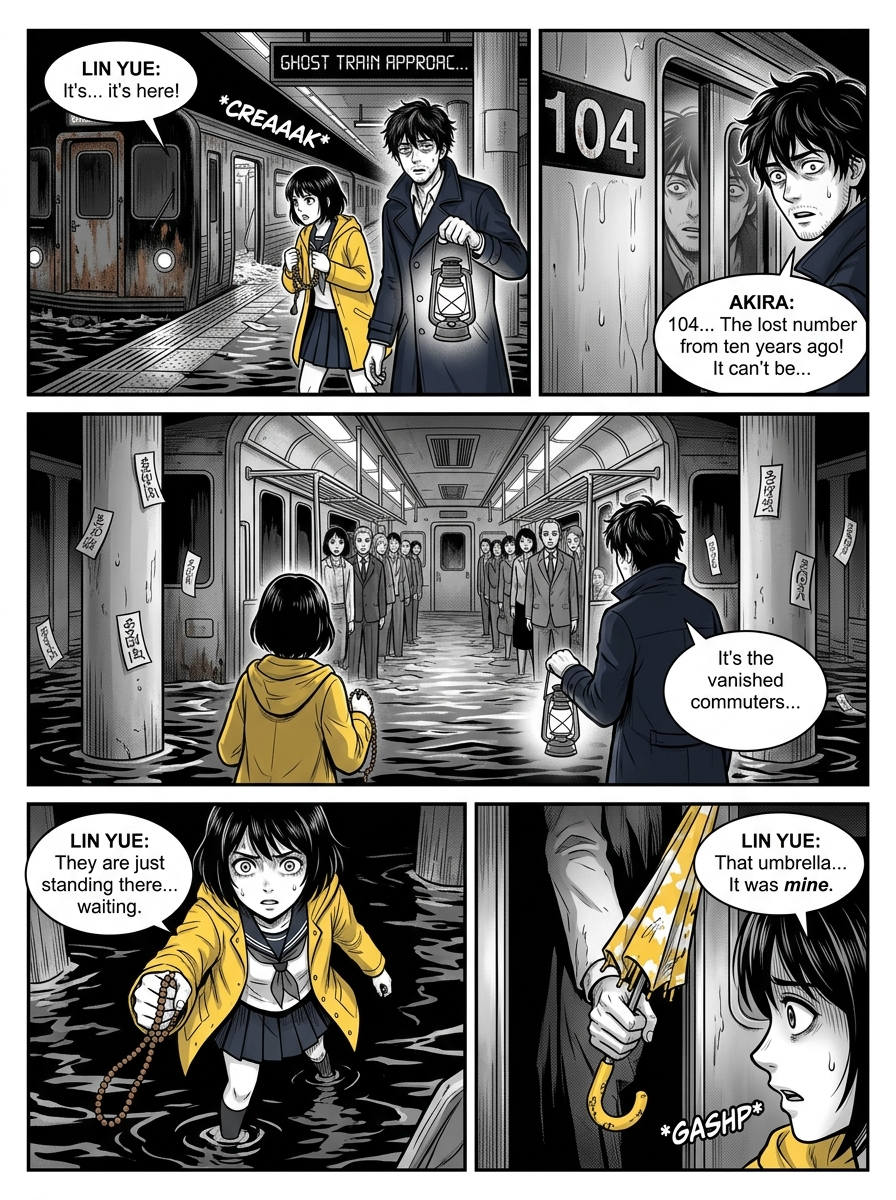


Testing Latest standard/pro image model: gemini-3-pro-image-preview (Nano Banana Pro Preview)
Docs: https://ai.google.dev/gemini-api/docs/image-generation
Pricing: https://ai.google.dev/gemini-api/docs/pricing
Removed SVG placeholder reference images for this real Gemini run because the Gemini image API rejects image/svg+xml inline references.


{
  "runName": "google-pro-latest",
  "model": "gemini-3-pro-image-preview",
  "marketingName": "Nano Banana Pro Preview",
  "provider": "image:google:gemini_image:gemini-3-pro-image-preview",
  "style": {
    "id": "manga",
    "name": "Manga",
    "prompt": "Japanese manga style, clean precise black linework, screen tone shading, expressive eyes, dynamic speed lines, black and white with impact effects"
  },
  "pageNumber": 2,
  "characterReferenceCount": 0,
  "previousPageReferenceCount": 0,
  "metadataRuntimeSeconds": 0.027,
  "imageRuntimeSeconds": 49.098,
  "totalRuntimeSeconds": 49.124,
  "metadataEstimatedCost": "0.0000 USD",
  "imageEstimatedCost": "0.1340 USD",
  "totalEstimatedCost": "0.1340 USD",
  "savedImagePath": "f:\\Documents\\GitHub\\AI_TRPG_616\\version 3.0\\artifacts\\comic_generation_notebook\\comic-page-google-pro-latest-20260413-175150.jpg",
  "billingNote": "Estimated from Google Gemini API pricing for the configured image size unless the server returned a cost 

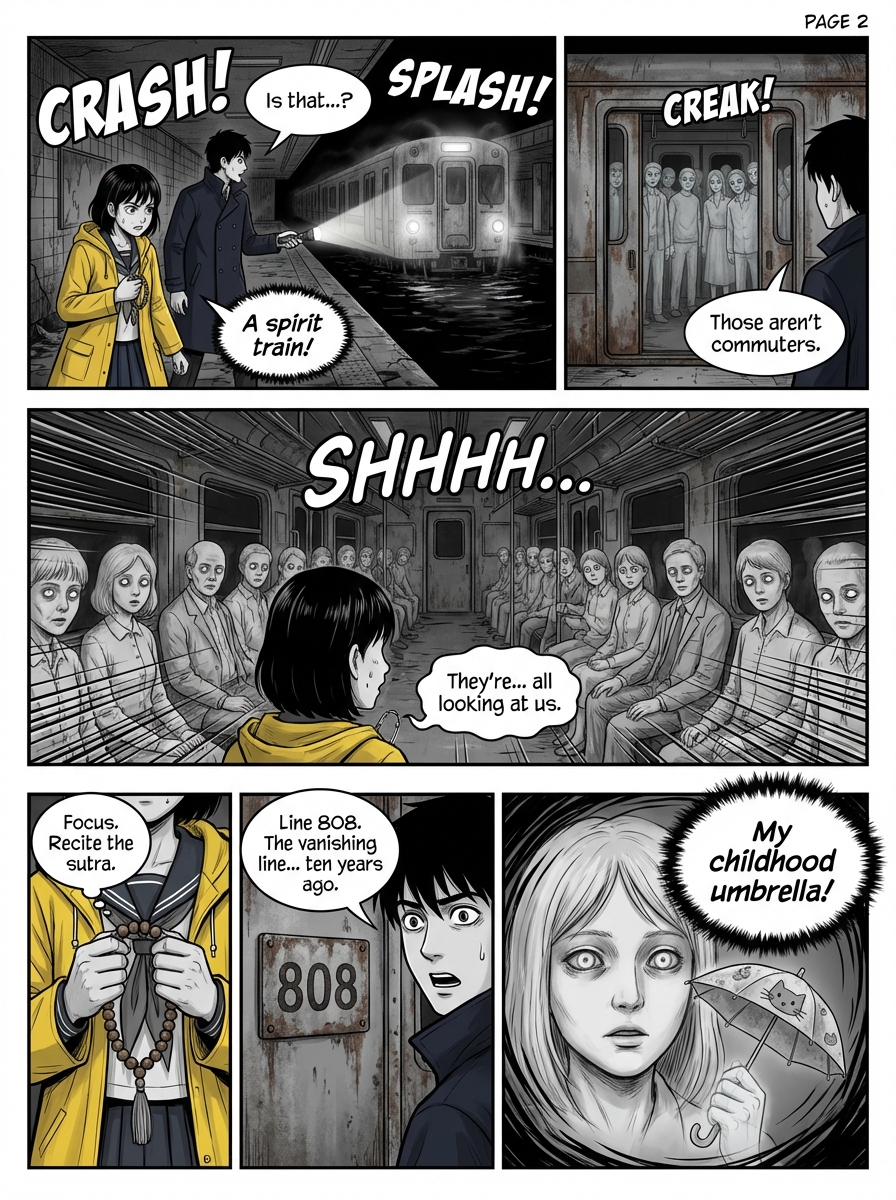


########################################################################################
Latest Google image model test summary
[
  {
    "runName": "google-fast-latest",
    "model": "gemini-3.1-flash-image-preview",
    "marketingName": "Nano Banana 2 Preview",
    "provider": "image:google:gemini_image:gemini-3.1-flash-image-preview",
    "style": {
      "id": "manga",
      "name": "Manga",
      "prompt": "Japanese manga style, clean precise black linework, screen tone shading, expressive eyes, dynamic speed lines, black and white with impact effects"
    },
    "pageNumber": 2,
    "characterReferenceCount": 0,
    "previousPageReferenceCount": 0,
    "metadataRuntimeSeconds": 0.027,
    "imageRuntimeSeconds": 14.597,
    "totalRuntimeSeconds": 14.624,
    "metadataEstimatedCost": "0.0000 USD",
    "imageEstimatedCost": "0.0670 USD",
    "totalEstimatedCost": "0.0670 USD",
    "savedImagePath": "f:\\Documents\\GitHub\\AI_TRPG_616\\version 3.0\\artifacts\\comic_generation_notebo

In [5]:
normalized_previous_pages = normalize_previous_pages(PREVIOUS_PAGES)
results = []

for run in LATEST_GOOGLE_IMAGE_RUNS:
    print("\n" + "=" * 88)
    print(f"Testing {run['label']}: {run['model']} ({run['marketingName']})")
    print(f"Docs: {run['docsUrl']}")
    print(f"Pricing: {run['pricingUrl']}")

    runtime_image_model_config = {
        **BASE_RUNTIME_IMAGE_MODEL_CONFIG,
        "model": run["model"],
        "imageSize": run["imageSize"],
        "aspectRatio": run["aspectRatio"],
    }
    effective_reference_images = build_effective_reference_images(
        REFERENCE_IMAGES,
        IMAGE_PROFILE_ID,
        KEEP_SVG_PLACEHOLDER_REFERENCES_FOR_REAL_MODELS,
    )
    page_payload = {
        "storyPrompt": STORY_PROMPT,
        "styleId": STYLE_ID,
        "storyMemorySummary": STORY_MEMORY_SUMMARY,
        "previousPages": normalized_previous_pages,
        "referenceImages": effective_reference_images,
        "negativePrompt": NEGATIVE_PROMPT,
        "allowFallback": ALLOW_FALLBACK,
        "imageProfileId": IMAGE_PROFILE_ID,
        "runtimeImageModelConfig": runtime_image_model_config,
    }

    page_started = perf_counter()
    try:
        page_result = post_json("/api/comics/generate-page", page_payload)
        page_elapsed = perf_counter() - page_started
        image_cost_amount, image_cost_currency = extract_estimated_cost(page_result)
        if image_cost_amount is None:
            image_cost_amount, image_cost_currency = estimate_google_image_cost(
                run["model"],
                run["imageSize"],
            )

        total_elapsed = metadata_elapsed + page_elapsed
        if metadata_cost_currency == image_cost_currency and metadata_cost_currency is not None:
            total_cost_amount = (metadata_cost_amount or 0.0) + (image_cost_amount or 0.0)
            total_cost_currency = metadata_cost_currency
        elif metadata_cost_amount is None and image_cost_amount is not None:
            total_cost_amount, total_cost_currency = image_cost_amount, image_cost_currency
        elif image_cost_amount is None and metadata_cost_amount is not None:
            total_cost_amount, total_cost_currency = metadata_cost_amount, metadata_cost_currency
        else:
            total_cost_amount, total_cost_currency = None, None

        output_path = save_generated_image(page_result["imageUrl"], make_output_stem(run["runName"]))
        result_summary = {
            "runName": run["runName"],
            "model": run["model"],
            "marketingName": run["marketingName"],
            "provider": page_result["provider"],
            "style": page_result["style"],
            "pageNumber": page_result["pageNumber"],
            "characterReferenceCount": page_result["characterReferenceCount"],
            "previousPageReferenceCount": page_result["previousPageReferenceCount"],
            "metadataRuntimeSeconds": round(metadata_elapsed, 3),
            "imageRuntimeSeconds": round(page_elapsed, 3),
            "totalRuntimeSeconds": round(total_elapsed, 3),
            "metadataEstimatedCost": format_cost(metadata_cost_amount, metadata_cost_currency),
            "imageEstimatedCost": format_cost(image_cost_amount, image_cost_currency),
            "totalEstimatedCost": format_cost(total_cost_amount, total_cost_currency),
            "savedImagePath": str(output_path),
            "billingNote": "Estimated from Google Gemini API pricing for the configured image size unless the server returned a cost object.",
        }
        print(json.dumps(result_summary, ensure_ascii=False, indent=2))
        print("\nFinal prompt preview:\n")
        print(page_result["revisedPrompt"][:2000])
        if len(page_result["revisedPrompt"]) > 2000:
            print("\n...[prompt truncated for display]...")
        display_generated_image(output_path)
        results.append(result_summary)
    except Exception as exc:
        page_elapsed = perf_counter() - page_started
        failure_summary = {
            "runName": run["runName"],
            "model": run["model"],
            "marketingName": run["marketingName"],
            "imageRuntimeSeconds": round(page_elapsed, 3),
            "status": "failed",
            "error": str(exc),
        }
        print(json.dumps(failure_summary, ensure_ascii=False, indent=2))
        results.append(failure_summary)

print("\n" + "#" * 88)
print("Latest Google image model test summary")
print(json.dumps(results, ensure_ascii=False, indent=2))
